<a href="https://colab.research.google.com/github/ShathaAI/ML_CourseProject/blob/main/Adult%20Income/Adult_Income_Supervise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Supervised Models***

In [89]:
# Library
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Preprocessing**

In [ ]:
# Download the Adult_Income dataset from Kaggle
dataset_path = kagglehub.dataset_download('serpilturanyksel/adult-income')

# construct the full path to the adult11.csv file.
file_path = os.path.join(dataset_path, 'adult11.csv')

# Load the dataset using pandas
adult = pd.read_csv(file_path)
adult.head()

In [ ]:
# Find Missing Values
adult.isnull().sum().head()

In [ ]:
# label encoding for (income); convert  <=50K to 1 & >50K to 0
adult['salary'] = adult['salary'].map({'<=50K': 0, '>50K': 1})
adult.head()

In [ ]:
# Encode the categorical columns (using label encode)
categorical_col = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country'] # All categorical columns

# Apply Label encoding
for col in categorical_col:
    adult[col] = pd.Categorical(adult[col]).codes
display(adult.head())

In [94]:
# Separate features (X) and target (y)
X_adult = adult.drop('salary', axis=1)
y_adult = adult['salary']

In [95]:
# (( Split the data into training and testing sets "70% train, 30% test" ))
X_adult_test, X_adult_train, y_adult_test, y_adult_train = train_test_split(X_adult, y_adult, test_size=0.3, random_state=42)

In [96]:
# Standardiztion
scaler = StandardScaler()
# just select numerical column
num_of_col = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X_adult_train_scaled = scaler.fit_transform(X_adult_train[num_of_col])
X_adult_test_scaled = scaler.transform(X_adult_test[num_of_col])

# **Model Building & Evaluation then Visualization**

> ***Logistic Regression model***

In [ ]:
# Logistic Regression model
LR_model = LogisticRegression(max_iter=2500)

# Train the model
LR_model.fit(X_adult_train_scaled, y_adult_train)

In [ ]:
# Making predictions on the test set
y_adult_pred_LR = LR_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_LR)
print()
print("Actual values:", y_adult_test.values)

In [99]:
# Compute metrics Logistic Regression
LR_accuracy_adult = accuracy_score(y_adult_test, y_adult_pred_LR) # accuracy

LR_precision_adult = precision_score(y_adult_test, y_adult_pred_LR) # precision

LR_recall_adult = recall_score(y_adult_test, y_adult_pred_LR) # recall

LR_f1_adult = f1_score(y_adult_test, y_adult_pred_LR) # f1

LR_roc_auc_adult = roc_auc_score(y_adult_test, LR_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("Logistic Regression Evaluation:")
print(f"Accuracy: {LR_accuracy_adult:.4f}")
print(f"Precision: {LR_precision_adult:.4f}")
print(f"Recall: {LR_recall_adult:.4f}")
print(f"F1-Score: {LR_f1_adult:.4f}")
print(f"ROC-AUC Score: {LR_roc_auc_adult:.4f}")

Logistic Regression Evaluation:
Accuracy: 0.8128
Precision: 0.7117
Recall: 0.3795
F1-Score: 0.4950
ROC-AUC Score: 0.8291


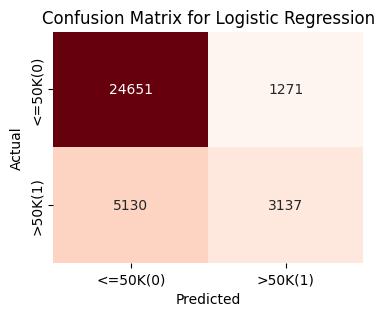

In [100]:
# confusion matrices for LR
LR_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_LR)
plt.figure(figsize=(4, 3))
sns.heatmap(LR_cm_adult, annot=True, fmt='d', cmap='Reds', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

> ***Naive Bayes model***

In [ ]:
# Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_adult_train_scaled, y_adult_train)

In [102]:
# Making predictions on the test set
y_adult_pred_nb = nb_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_nb)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics
nb_accuracy = accuracy_score(y_adult_test, y_adult_pred_nb) # accuracy

nb_precision = precision_score(y_adult_test, y_adult_pred_nb) # precision

nb_recall = recall_score(y_adult_test, y_adult_pred_nb) # recall

nb_f1 = f1_score(y_adult_test, y_adult_pred_nb) # f1

nb_roc_auc = roc_auc_score(y_adult_test, nb_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nNaive Bayes Evaluation:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(f"ROC-AUC Score: {nb_roc_auc:.4f}")

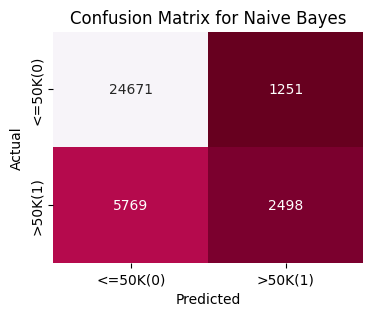

In [104]:
# confusion matrices for Naive Bayes
nb_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_nb)
plt
plt.figure(figsize=(4, 3))
sns.heatmap(nb_cm_adult, annot=True, fmt='d', cmap='PuRd_r', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()

> ***BernoulliNB***

In [ ]:
# BernoulliNB
b_model = BernoulliNB()

# Train the model
b_model.fit(X_adult_train_scaled, y_adult_train)

In [106]:
# # Making predictions on the test set
y_adult_pred_b = b_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_b)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics
b_accuracy = accuracy_score(y_adult_test, y_adult_pred_b) # accuracy

b_precision = precision_score(y_adult_test, y_adult_pred_b) # precision

b_recall = recall_score(y_adult_test, y_adult_pred_b) # recall

b_f1 = f1_score(y_adult_test, y_adult_pred_b) # f1

b_roc_auc = roc_auc_score(y_adult_test, b_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nBernoulli Naive Bayes Evaluation:")
print(f"Accuracy: {b_accuracy:.4f}")
print(f"Precision: {b_precision:.4f}")
print(f"Recall: {b_recall:.4f}")
print(f"F1-Score: {b_f1:.4f}")
print(f"ROC-AUC Score: {b_roc_auc:.4f}")

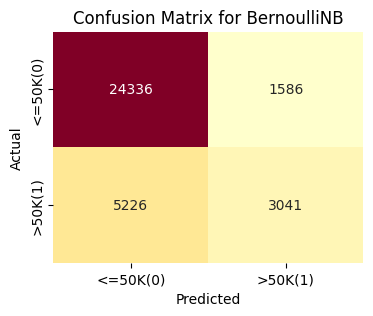

In [108]:
# confusion matrices for BernoulliNB
b_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_b)
plt.figure(figsize=(4, 3))
sns.heatmap(b_cm_adult, annot=True, fmt='d', cmap='YlOrRd', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for BernoulliNB')
plt.show()

> ***Support Vector Machine model***

In [ ]:
# SVM
svm_model = SVC(probability=True)

# Train the model
svm_model.fit(X_adult_train_scaled, y_adult_train)

In [110]:
# # Making predictions on the test set
y_adult_pred_svm = svm_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_svm)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics
svm_accuracy = accuracy_score(y_adult_test, y_adult_pred_svm) # accuracy

svm_precision = precision_score(y_adult_test, y_adult_pred_svm) # precision

svm_recall = recall_score(y_adult_test, y_adult_pred_svm) # recall

svm_f1 = f1_score(y_adult_test, y_adult_pred_svm) # f1

svm_roc_auc = roc_auc_score(y_adult_test, svm_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nSupport Vector Machine Evaluation:")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print(f"ROC-AUC Score: {svm_roc_auc:.4f}")

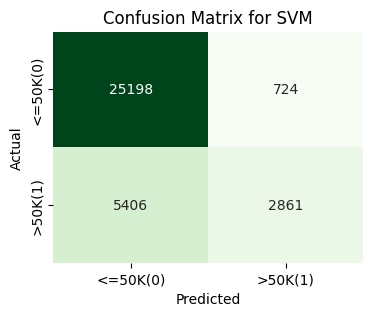

In [112]:
# confusion matrices for SVM
svm_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_svm)
plt.figure(figsize=(4, 3))
sns.heatmap(svm_cm_adult, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()

# **Model Performance Comparison**

In [113]:
# Get the predicted probabilities for the positive class for each model
y_prob_LR = LR_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_bir = b_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_svm = svm_model.predict_proba(X_adult_test_scaled)[:, 1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_log, tpr_log, _ = roc_curve(y_adult_test, y_prob_LR)
fpr_gnb, tpr_gnb, _ = roc_curve(y_adult_test, y_prob_nb)
fpr_bnb, tpr_bnb, _ = roc_curve(y_adult_test, y_prob_bir)
fpr_svm, tpr_svm, _ = roc_curve(y_adult_test, y_prob_svm)

# Calculate the Area Under the ROC Curve
auc_log = roc_auc_score(y_adult_test, y_prob_LR)
auc_gnb = roc_auc_score(y_adult_test, y_prob_nb)
auc_bnb = roc_auc_score(y_adult_test, y_prob_bir)
auc_svm = roc_auc_score(y_adult_test, y_prob_svm)

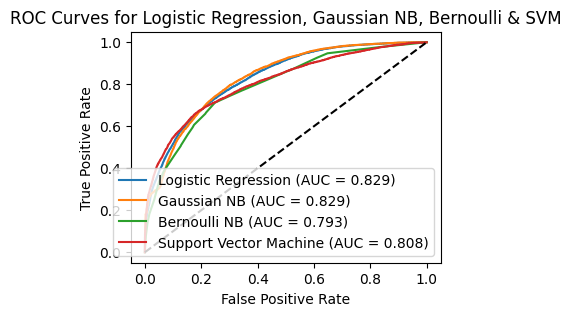

In [114]:
# plot the carve
plt.figure(figsize=(4, 3))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb, tpr_gnb, label=f"Gaussian NB (AUC = {auc_gnb:.3f})")
plt.plot(fpr_bnb, tpr_bnb, label=f"Bernoulli NB (AUC = {auc_bnb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"Support Vector Machine (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression, Gaussian NB, Bernoulli & SVM")
plt.legend(loc="lower right")
plt.show()

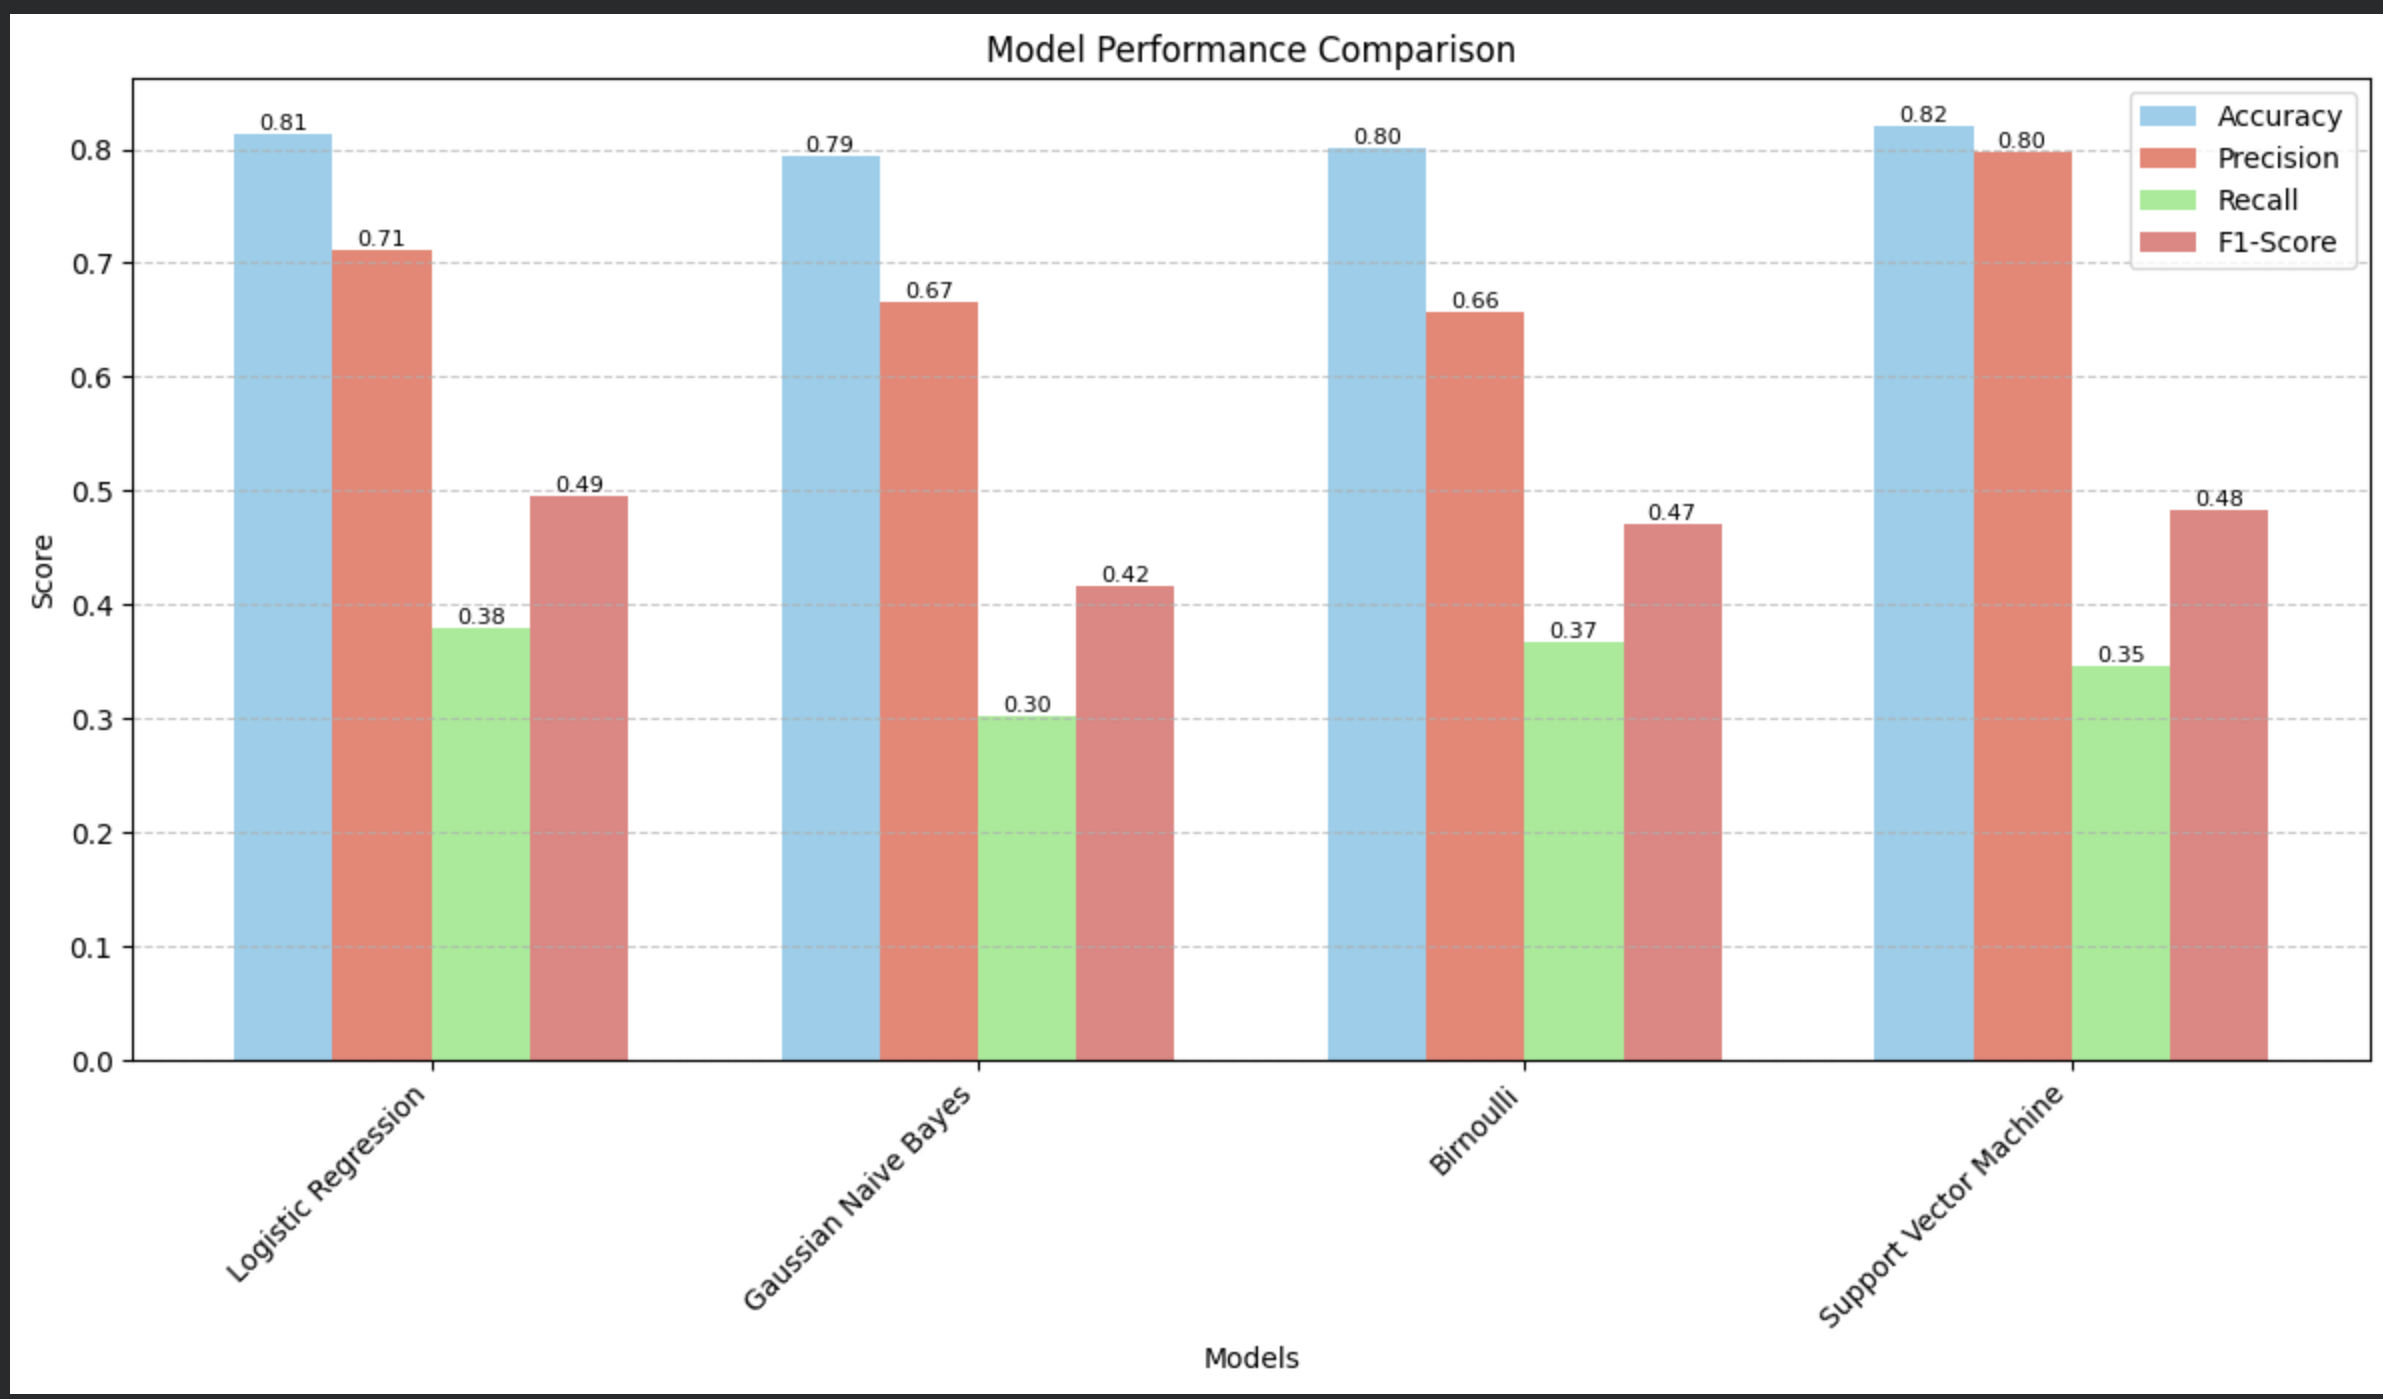